<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Test_Grab_Transbport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'>**dated 26.07.2026 9pm**

#**Chapter 1. Setup and load libraries**

In [1]:
# Core Libraries
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries and preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42

print('Setup complete')

Setup complete


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Chapter 2. Upload and Read Dataset**

In [40]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub fileynth
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/synthetic_grab_transport_v3_10000_23pct_cancel.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled


#**Chapter 3. Set up OpenAI**

In [5]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


#**Chapter 4. Quick dataset inspection before using an LLM**

In [6]:
print('Shape:', df.shape)

display(df.head())

print('\nInfo:')
display(df.info())

print('\nColumns:', df.columns.tolist())

print("\nDescribe:")
display(df.describe(include='all').transpose())

missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

duplicate_count = df.duplicated().sum()
print("\nDuplicate count:", duplicate_count)

Shape: (10000, 49)


,booking_id,booking_datetime,booking_hour,day_of_week,month,is_weekend,is_peak_hour,is_late_night,public_holiday,pickup_zone,...,traffic_level,surge_multiplier,surge_changed_after_booking,promo_applied,promo_discount_sgd,estimated_fare_sgd,app_version,network_quality,customer_cancelled,cancel_reason
0,BK2026007041,6/3/2026 0:10,0,Friday,3,0,0,1,0,Queenstown,...,Medium,1.10,0,0,0,11.66,Current,Good,0,Not Cancelled
1,BK2026017909,11/6/2026 9:31,9,Thursday,6,0,1,0,0,CBD,...,Severe,1.15,0,1,10,6.64,One version behind,Good,0,Not Cancelled
2,BK2026010896,9/4/2026 9:42,9,Thursday,4,0,1,0,0,Sentosa,...,Low,1.49,0,0,0,40.07,Current,Poor,1,Changed plans/weather
3,BK2026003508,1/2/2026 23:47,23,Sunday,2,1,0,1,0,CBD,...,Low,1.00,0,1,3,21.48,Current,Good,0,Not Cancelled
4,BK2026013146,29/4/2026 12:57,12,Wednesday,4,0,0,0,0,Jurong East,...,Medium,1.00,0,0,0,7.12,Current,Good,0,Not Cancelled



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   booking_id                       10000 non-null  object 
 1   booking_datetime                 10000 non-null  object 
 2   booking_hour                     10000 non-null  int64  
 3   day_of_week                      10000 non-null  object 
 4   month                            10000 non-null  int64  
 5   is_weekend                       10000 non-null  int64  
 6   is_peak_hour                     10000 non-null  int64  
 7   is_late_night                    10000 non-null  int64  
 8   public_holiday                   10000 non-null  int64  
 9   pickup_zone                      10000 non-null  object 
 10  pickup_zone_type                 10000 non-null  object 
 11  dropoff_zone                     10000 non-null  object 
 12  dropoff_zone

None


Columns: ['booking_id', 'booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled', 'cancel_reason']

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,10000,10000,BK2026003811,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_datetime,10000,9796,28/6/2026 14:54,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_hour,10000.0,NaN,NaN,NaN,11.7025,6.839303,0.0,6.0,12.0,18.0,23.0
day_of_week,10000,7,Thursday,1475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,10000.0,NaN,NaN,NaN,3.4967,1.70114,1.0,2.0,4.0,5.0,6.0
is_weekend,10000.0,NaN,NaN,NaN,0.2831,0.450527,0.0,0.0,0.0,1.0,1.0
is_peak_hour,10000.0,NaN,NaN,NaN,0.3021,0.459191,0.0,0.0,0.0,1.0,1.0
is_late_night,10000.0,NaN,NaN,NaN,0.2744,0.446234,0.0,0.0,0.0,1.0,1.0
public_holiday,10000.0,NaN,NaN,NaN,0.0324,0.177069,0.0,0.0,0.0,0.0,1.0
pickup_zone,10000,15,CBD,918,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values:
 booking_id                            0
booking_datetime                      0
booking_hour                          0
day_of_week                           0
month                                 0
is_weekend                            0
is_peak_hour                          0
is_late_night                         0
public_holiday                        0
pickup_zone                           0
pickup_zone_type                      0
dropoff_zone                          0
dropoff_zone_type                     0
airport_trip                          0
cbd_trip                              0
distance_km                           0
estimated_trip_duration_min           0
vehicle_type                          0
payment_method                        0
customer_segment                      0
loyalty_tier                       3268
customer_tenure_days                  0
rides_last_7_days                     0
rides_last_30_days                    0
customer_cancel_rate_90

In [9]:
# PROMPT - LLM-assisted problem framing

prompt_framing = f"""
You are an experienced data scientist specialising in machine learning for business problems.

Your task is to translate the following business problem into a machine learning modelling objective.
=======================
DATASET PREVIEW
=======================
{df.head()}

=========================
BUSINESS CONTEXT
=========================
Business Problem:
Grab Ride Operations Manager has observed a high rate of customer cancellations before the trip commencement over the past few months.

Business Objective:
Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.

Business Goal:
Reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.

Dataset Context:
The dataset contains synthetic ride-hailing booking data.
Each row represents one booking made by a customer.
The dataset includes customer information, booking details, driver availability, pricing, weather, traffic conditions, and booking outcomes.

=========================
TASK
=========================
Answer the following questions:

1. What should the machine learning modelling objective be?

2. Which column should be used as the target variable? Explain why.

3. Which evaluation model(s) and metric(s) would you recommend for this prediction problem?
Explain why these metrics would be meaningful and easy for business stakeholders to understand.

4. Who are the main business stakeholders that would use the model?

5. Identify three potential risks or pitfalls when developing or deploying this model.

=========================
IMPORTANT
=========================
Use ONLY the information provided in the business context and dataset profile.
Do NOT invent columns, business processes or stakeholders that are not supported by the information provided.
If an answer requires assumptions, clearly label them as "Assumption".
If information is not available, state the assumptions you are making.
Present your answers using clear headings and concise explanations suitable for a university report.
"""
print('=== Prompt to send ===')
print(prompt_framing[:2000])


response_framing = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_framing
)
print('\n=== LLM response ===')
print(response_framing.output_text)



=== Prompt to send ===

You are an experienced data scientist specialising in machine learning for business problems.

Your task is to translate the following business problem into a machine learning modelling objective.
DATASET PREVIEW
     booking_id booking_datetime  booking_hour day_of_week  month  is_weekend  \
0  BK2026007041    6/3/2026 0:10             0      Friday      3           0   
1  BK2026017909   11/6/2026 9:31             9    Thursday      6           0   
2  BK2026010896    9/4/2026 9:42             9    Thursday      4           0   
3  BK2026003508   1/2/2026 23:47            23      Sunday      2           1   
4  BK2026013146  29/4/2026 12:57            12   Wednesday      4           0   

   is_peak_hour  is_late_night  public_holiday  pickup_zone  ...  \
0             0              1               0   Queenstown  ...   
1             1              0               0          CBD  ...   
2             1              0               0      Sentosa  ...   
3   

#**Chapter 5. Build Payload Text**

In [10]:
#===== Chapter 5. Build Payload Text =====#

payload_text = ''

# 0. Business context and objective
payload_text += '=== BUSINESS OBJECTIVE ===\n'
payload_text += 'Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.\n'
payload_text += 'The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.\n'
payload_text += 'Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.\n'
payload_text += 'Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.\n'
payload_text += 'Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.\n'
payload_text += 'Questions:\n'
payload_text += '- Which features influence customer cancellation?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)



=== BUSINESS OBJECTIVE ===
Dataset context: The dataset contains ride-hailing booking data. Each row represents one booking made by a customer.
The dataset includes customer information, booking details, driver availability, weather, traffic conditions, and booking outcomes.
Business Goal: Develop a machine learning model to predict the probability that a customer will cancel a ride before trip commencement.
Utimately to reduce the customer pre-trip cancellation rate by enabling proactive operational interventions.
Intended Users: Grab Ride Operations Manager whose one of his goal is to reduce the customer pre-trip cancellation rate.
Questions:
- Which features influence customer cancellation?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 10000
Columns: 49

=== SAMPLE RECORDS ===
  booking_id booking_datetime  booking_hour day_of_week  month  is_weekend  is_peak_hour  is_late_night  public_holiday pickup_zone pickup_zone_type dropoff_zone drop

#**Chapter 6. Prompt LLM to review Data Quality using Payload Text**

In [11]:
#===== Chapter 6. Quality Assessment =====#

prompt_quality = f"""
You are an expert data scientist with extensive knowledge of tree-based models.
Always justify recommendations using reasoning trace based ONLY on the dataset profile.
============================
DATASET PROFILE
============================
{payload_text}

============================
TASK
============================
Assess the dataset's quality and modelling readiness.

1. Identify all confirmed data quality or modelling-readiness issues.

For each issue, provide:
- Issue
- Column(s) affected
- Evidence from the dataset profile
- Why it may affect analysis or modelling
- Recommended action
- Priority (High / Medium / Low)

2. Identify any potential issues that require further investigation but cannot be confirmed from the dataset profile alone.
3. Identify any features which are higly correlated with other features.
4. Highlight the strengths of the dataset (for example, no missing values, no duplicates, appropriate data types, etc.).

5. State whether the dataset is ready for machine learning modelling using ONE of the following ratings:
- Ready
- Ready with Minor Cleaning
- Ready with Moderate Cleaning
- Not Ready
Provide a brief justification.

6. Recommend the Top 5 next steps before modelling.

7. Provide simple and executable python script to handle the identified issues.
- Original dataset: df
- Define one helper function for each issue.
- Then define a wrapper function that calls these helper with true false option as user choice
- Provide a single line of code to run the overall wrapper function. Save the final dataset to cleaned_df.
- Do not split data, encode categorical columns or model first.

========================
IMPORTANT INSTRUCTIONS
========================

- Use only the information contained in the dataset profile.
- Do NOT assume information that is not provided.
- If evidence is unavailable, state "Not available" instead of guessing.
- Reference the relevant dataset profile section whenever possible (e.g., Missing Values, Numeric Summary, Correlation Matrix, Warning Checks).
- Do NOT recommend dropping a column solely because it appears in a warning.
- Treat ID-like, high-cardinality, constant, near-constant and outlier warnings as items requiring investigation, not automatic removal.
- Do NOT treat correlation as proof of causation.
- Do NOT recommend removing outliers unless there is evidence they are invalid or unsuitable for the business objective.
- If skewness, outlier summary, feature importance, or other analyses are not included in the dataset profile, state that they were not available instead of inferring results.
- Distinguish clearly between confirmed issues and potential issues.
- Keep recommendations practical, concise, and suitable for a data analytics student.

========================
OUTPUT FORMAT
========================

Overall Modelling Readiness
---------------------------
Readiness Rating:
Brief Justification:

Confirmed Issues
----------------
For each issue, use the following format:

Issue:
Column(s):
Evidence:
Impact:
Recommended Action:
Priority:

Potential Issues Requiring Investigation
-----------------------------------------
For each potential issue, use:

Issue:
Reason Further Investigation is Needed:

Dataset Strengths
-----------------
- ...
- ...
- ...

Checks with No Issues
---------------------
- ...
- ...
- ...

Top 5 Recommended Next Steps
----------------------------
1.
2.
3.

Overall Summary
---------------
Provide a concise summary (3–5 sentences) describing the dataset's overall quality and readiness for machine learning modelling.
"""

response_quality= client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_quality
)
print('\n=== LLM response ===')
print(response_quality.output_text)





=== LLM response ===
Overall Modelling Readiness
---------------------------
Readiness Rating: **Ready with Moderate Cleaning**

Brief Justification:
- The dataset has **no missing values** except **loyalty_tier (32.68%)** (Missing Values section), and **no duplicate rows** (Simple Warning Checks).  
- However, there are **strong modelling-readiness risks**: potential **target leakage proxies** (e.g., `booking_id` flagged as leakage candidate), and several **high-cardinality / near-unique identifiers** plus **outlier-heavy / skewed numeric features** that require handling/verification (Unique Values per Column, Skewness, Outlier Summary).  
- Because the modeling objective is pre-trip cancellation, any mismatch in how variables are recorded “before trip commencement” would need verification; that specific timing risk cannot be confirmed from the profile alone.

Confirmed Issues
----------------
1) **High missingness in loyalty tier**
- **Issue:** Missing values present in a key catego

#**Chapter 7. Data Cleaning (selective) based on LLM's Data Quality Review**

In [41]:
# ===== Chapter 7. Data Cleaning =====
# Drop booking_id, handle missing loyalty_tier, parse booking_datetime, and drop cancel_reason

import pandas as pd

# ---------- fill missing loyalty_tier ---------- #
def fix_missing_loyalty_tier(df, use_true_false=True):
    """
    If True: fill missing loyalty_tier with 'Unknown' category.
    """
    if not use_true_false:
        return df
    if 'loyalty_tier' in df.columns:
        df = df.copy()
        df['loyalty_tier'] = df['loyalty_tier'].astype('object')
        df['loyalty_tier'] = df['loyalty_tier'].fillna('Unknown')
    return df

# ---------- drop ID-like booking_id ---------- #
def drop_booking_id(df, use_true_false=True):
    """
    If True: drop ID-like booking_id to avoid memorization.
    """
    if not use_true_false:
        return df
    if 'booking_id' in df.columns:
        df = df.drop(columns=['booking_id'])
    return df

# ---------- drop cancel_reason ---------- #
def drop_cancel_reason_if_label_proximate(df, use_true_false=True):
    """
    If True: drop cancel_reason to prevent using post-outcome proxy information.
    """
    if not use_true_false:
        return df
    if 'cancel_reason' in df.columns:
        df = df.drop(columns=['cancel_reason'])
    return df

# ---------- parse booking_datetime ---------- #
def parse_booking_datetime_safely(df, use_true_false=True):
    """
    If True: attempt to parse booking_datetime robustly; keep original columns used elsewhere.
    """
    if not use_true_false:
        return df
    if 'booking_datetime' in df.columns:
        df = df.copy()
        # Try day-first parsing; if some formats are month-first, this may still work in practice.
        df['booking_datetime_parsed'] = pd.to_datetime(df['booking_datetime'], errors='coerce', dayfirst=True)
        # Do not drop original booking_datetime to avoid breaking downstream references.
    return df

# ---------- Wrapper ----------
def clean_dataset_wrapper(df,
                          fix_loyalty=True,
                          drop_id=True,
                          drop_cancel_reason=True,
                          parse_datetime=True):
    df_clean = df
    df_clean = fix_missing_loyalty_tier(df_clean, use_true_false=fix_loyalty)
    df_clean = drop_booking_id(df_clean, use_true_false=drop_id)
    df_clean = drop_cancel_reason_if_label_proximate(df_clean, use_true_false=drop_cancel_reason)
    df_clean = parse_booking_datetime_safely(df_clean, use_true_false=parse_datetime)
    return df_clean

# ---------- One line to run ----------
cleaned_df = clean_dataset_wrapper(df, fix_loyalty=True, drop_id=True, drop_cancel_reason=True, parse_datetime=True)

# --------- Save final dataset to Google Drive for reference -------- #
cleaned_df.to_csv(
    "/content/drive/MyDrive/cleaned_df.csv",
    index=False
)
print('Data Cleaning is done.')


Data Cleaning is done.


#**Chapter 8. Compare before and after clean dataset**

In [13]:
print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

# Columns in each dataframe
df_cols = set(df.columns)
cleaned_cols = set(cleaned_df.columns)

# Compare
removed_cols = sorted(df_cols - cleaned_cols)
added_cols = sorted(cleaned_cols - df_cols)
common_cols = sorted(df_cols & cleaned_cols)

print(f"Original df columns      : {len(df_cols)}")
print(f"Cleaned_df columns       : {len(cleaned_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original rows: 10000
Cleaned rows: 10000

Missing values after cleaning:


,0
booking_datetime,0
booking_hour,0
day_of_week,0
month,0
is_weekend,0
is_peak_hour,0
is_late_night,0
public_holiday,0
pickup_zone,0
pickup_zone_type,0



Columns after cleaning:
['booking_datetime', 'booking_hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'public_holiday', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone', 'dropoff_zone_type', 'airport_trip', 'cbd_trip', 'distance_km', 'estimated_trip_duration_min', 'vehicle_type', 'payment_method', 'customer_segment', 'loyalty_tier', 'customer_tenure_days', 'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d', 'previous_customer_cancellations', 'avg_previous_wait_time_min', 'customer_rating', 'driver_rating', 'active_driver_supply_zone', 'booking_demand_zone', 'supply_demand_ratio', 'nearby_driver_count', 'drivers_declined_before_accept', 'driver_acceptance_time_sec', 'driver_distance_to_pickup_km', 'driver_eta_min', 'weather', 'is_raining', 'traffic_level', 'surge_multiplier', 'surge_changed_after_booking', 'promo_applied', 'promo_discount_sgd', 'estimated_fare_sgd', 'app_version', 'network_quality', 'customer_cancelled', 'booking_dateti

#**Chapter 7b. Further Data Cleaning**

In [14]:
prompt_clean2 = f"""
You are an expert data scientist with experience in tree-based regression models.
Input is cleaned_df, and output should be cleaned2_df.

Generate simple and executable Python codes to drop:
- 'booking_datetime_parsed'
- 'booking_datetime''
"""
response_clean2= client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_clean2
)
print('\n=== LLM response ===')
print(response_clean2.output_text)


=== LLM response ===
```python
# Drop specified columns from cleaned_df to create cleaned2_df
cleaned2_df = cleaned_df.drop(columns=['booking_datetime_parsed', 'booking_datetime'], errors='ignore')
```


In [42]:
# Drop specified columns from cleaned_df to create cleaned2_df
cols_to_drop = ['booking_datetime_parsed', 'booking_datetime']
cleaned2_df = cleaned_df.drop(columns=[c for c in cols_to_drop if c in cleaned_df.columns], errors='ignore')

In [43]:
# Compare before and after cleaning

# Columns in each dataframe
cleaned_cols = set(cleaned_df.columns)
cleaned2_cols = set(cleaned2_df.columns)

# Compare
removed_cols = sorted(cleaned_cols - cleaned2_cols)
added_cols = sorted(cleaned2_cols - cleaned_cols)
common_cols = sorted(cleaned_cols & cleaned2_cols)

print(f"Original df columns      : {len(cleaned_cols)}")
print(f"Cleaned_df columns       : {len(cleaned2_cols)}")
print(f"Common columns           : {len(common_cols)}")
print(f"Removed columns          : {len(removed_cols)}")
print(f"Added columns            : {len(added_cols)}")

print("\n=== Columns Removed from cleaned_df ===")
print(removed_cols)

print("\n=== Columns Added to cleaned_df ===")
print(added_cols)

Original df columns      : 48
Cleaned_df columns       : 46
Common columns           : 46
Removed columns          : 2
Added columns            : 0

=== Columns Removed from cleaned_df ===
['booking_datetime', 'booking_datetime_parsed']

=== Columns Added to cleaned_df ===
[]


#**Chapter 9. Prompt LLM to start a baseline modelling from Train/Test Split till Model Evaluation**

In [51]:
df = cleaned2_df

prompt_model = f"""
You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` for Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical and categorical columns.
- Exclude datetime columns from numerical preprocessing. Print any datetime
  columns found and drop them before modelling.
- Ensure all result tables are displayed clearly in Google Colab.
- When plotting ROC or Precision–Recall curves using RocCurveDisplay or PrecisionRecallDisplay,
  do not pass ax=plt.
  Either omit the ax parameter or create an Axes object with fig, ax = plt.subplots() and pass ax=ax.

Generate code to perform the following:

1. Create `X` and `y`, where `X` contains all input features and `y` is
   `customer_cancelled`.

2. Check the target distribution and display the count and percentage of
   each class.

3. Split the data into training and test sets using:
   - `test_size=0.2`
   - `random_state=42`
   - `stratify=y`

4. Identify:
   - numerical columns using `select_dtypes(include="number")`
   - categorical columns using
     `select_dtypes(include=["object", "category", "bool"])`
   - datetime columns separately

5. Create a preprocessing pipeline:
   - numerical features: median imputation followed by StandardScaler
   - categorical features: most-frequent imputation followed by
     OneHotEncoder(handle_unknown="ignore")

6. Create and train a baseline Logistic Regression model using:
   - `random_state=42`
   - `max_iter=1000`
   - `class_weight="balanced"`

7. Generate predictions:
   - training class predictions
   - test class predictions
   - training cancellation probabilities
   - test cancellation probabilities

8. Evaluate the model on both the training and test sets using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Average Precision

   Save the results in a DataFrame named `results_df`, with one row for the
   training set and one row for the test set.

9. Display the test classification report and provide a brief interpretation
   of:
   - true positives
   - true negatives
   - false positives
   - false negatives
   - whether the train and test results suggest overfitting

10. Perform 5-split cross-validation using `StratifiedShuffleSplit` with:
    - `n_splits=5`
    - `test_size=0.2`
    - `random_state=42`

11. During cross-validation, evaluate:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - Average Precision

    Save the mean and standard deviation of each validation metric in a
    DataFrame named `cv_results_df`.

12. Plot predicted cancellation probability by actual class using a boxplot.

13. Plot the confusion matrix with labels:
    - Not Cancelled
    - Cancelled

14. Plot an actual-versus-predicted class-count bar chart.

15. Plot the ROC curve and display the ROC-AUC value.

16. Plot the Precision-Recall curve and display the Average Precision value.

17. At the end, print a concise model interpretation explaining:
    - how well the model detects cancellations
    - the meaning of precision and recall in this business context
    - whether false positives or false negatives may be more costly
    - any limitations of evaluating only one model
"""

print('=== Prompt to send ===')
print(prompt_model)

response_model = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt_model
)
print('\n=== LLM response ===')
print(response_model.output_text)



=== Prompt to send ===

You are an expert data scientist with experience in binary classification models.

The pandas DataFrame is named `df`.
The target column is `customer_cancelled`, where:
- 0 = customer did not cancel
- 1 = customer cancelled

Generate simple, executable Python code with clear comments.
The code must be compatible with commonly used versions of scikit-learn.

Important requirements:
- Treat this as a binary classification problem, not regression.
- Do not use MAE, RMSE, MSE, MAPE, or R-squared.
- Use a scikit-learn Pipeline so preprocessing is fitted only on the training data.
- Use `random_state=42` where applicable.
- Use stratification when splitting the target.
- Handle unknown categorical values using
  `OneHotEncoder(handle_unknown="ignore")`.
- Use `max_iter=1000` for Logistic Regression.
- Use predicted class probabilities from
  `predict_proba(X_test)[:, 1]`.
- Do not assume specific feature names other than the target.
- Automatically identify numerical 

Target distribution (customer_cancelled):


,count,percent
customer_cancelled,,
0,7700,77.0
1,2300,23.0


No datetime columns found.
Number of numerical columns: 32
Number of categorical columns: 13


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
Train,0.9305,0.793956,0.942391,0.861829,0.985351,0.957337
Test,0.9370,0.818702,0.932609,0.871951,0.986210,0.963319



Test Classification Report:
              precision    recall  f1-score   support

           0     0.9790    0.9383    0.9582      1540
           1     0.8187    0.9326    0.8720       460

    accuracy                         0.9370      2000
   macro avg     0.8988    0.9355    0.9151      2000
weighted avg     0.9421    0.9370    0.9384      2000


Interpretation (based on Test set confusion matrix):
- True Positives (TP): 429 (cancelled customers correctly predicted as cancelled)
- True Negatives (TN): 1445 (not-cancelled customers correctly predicted as not cancelled)
- False Positives (FP): 95 (not-cancelled customers incorrectly predicted as cancelled)
- False Negatives (FN): 31 (cancelled customers incorrectly predicted as not cancelled)

Overfitting check: Train and Test metrics look reasonably similar (no strong sign of overfitting).


,mean,std
metric,,
Accuracy,0.927900,0.005595
Precision,0.794441,0.017777
Recall,0.926957,0.013454
F1-score,0.855435,0.009793
ROC-AUC,0.983342,0.002012
Average Precision,0.953146,0.007130


/tmp/ipykernel_1002/2454173378.py:243: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[str(c) for c in sorted(test_plot_df["actual_class"].unique())])


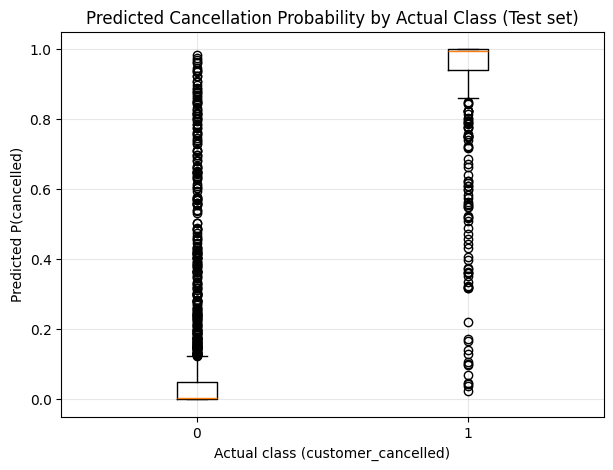

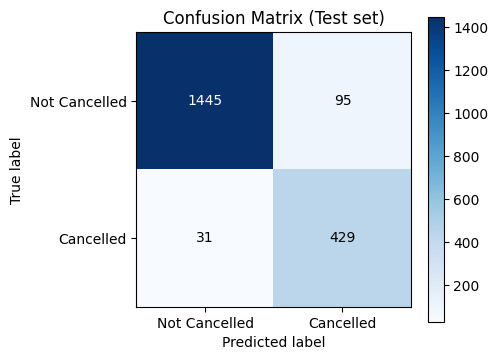

,Actual,Predicted
Not Cancelled,1540,1476
Cancelled,460,524


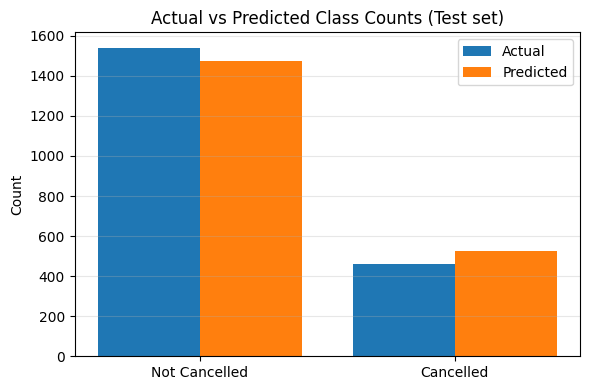

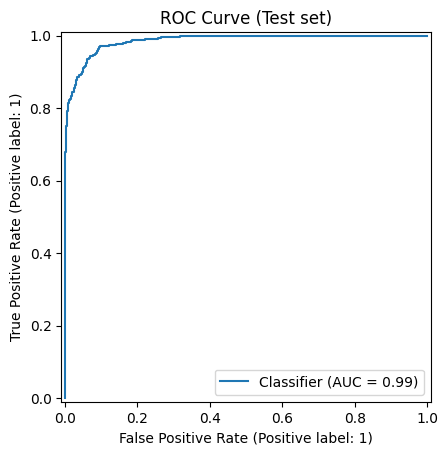

ROC-AUC (Test): 0.9862


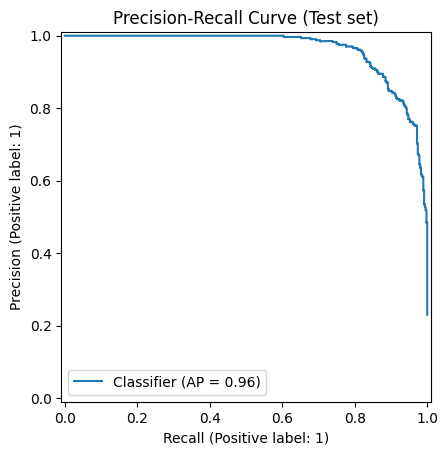

Average Precision (Test): 0.9633

Concise Model Interpretation:
- Detection of cancellations: On the Test set, the model achieved Recall=0.933 and Precision=0.819, indicating how effectively it finds cancelled customers while limiting incorrect 'cancelled' flags.
- Precision means: among customers predicted to cancel, precision=0.819 are truly cancelled.
- Recall means: among truly cancelled customers, recall=0.933 are correctly detected as cancelled.
- Costs: False Positives (FP=95) are predicted-cancelled but actually not; False Negatives (FN=31) are missed cancellations. If calling/retention intervention is costly for non-cancellations, FP may be more costly; if missing a cancellation is costly, FN may be more costly.
- Limitations: Metrics from a single train/test split can vary with sampling. Cross-validation helps, but one model may not capture nonlinear patterns; also, performance depends on the chosen decision threshold (default=0.5 for class labels).


In [52]:
# =========================
# Binary Classification with scikit-learn (Logistic Regression)
# Target: customer_cancelled (0/1)
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# If in Colab, nicer display by default
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# -------------------------
# 1. Create X and y
# -------------------------
X = df.drop(columns=["customer_cancelled"])
y = df["customer_cancelled"]

# -------------------------
# 2. Target distribution
# -------------------------
target_counts = y.value_counts().sort_index()
target_percents = (target_counts / len(y) * 100).round(2)

print("Target distribution (customer_cancelled):")
dist_df = pd.DataFrame({
    "count": target_counts,
    "percent": target_percents
})
display(dist_df)

# -------------------------
# 3. Train/test split (stratified)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 4. Identify numerical, categorical, datetime columns
# -------------------------
# Datetime columns separately (not included in numerical preprocessing)
datetime_cols = X.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
print(f"Datetime columns found ({len(datetime_cols)}): {datetime_cols}" if datetime_cols else "No datetime columns found.")

# Numerical: strictly numeric
numerical_cols = X.select_dtypes(include="number").columns.tolist()
# Categorical: object/category/bool (and exclude datetime columns already)
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

# Ensure we do not attempt to preprocess datetime columns as numeric
numerical_cols = [c for c in numerical_cols if c not in datetime_cols]
categorical_cols = [c for c in categorical_cols if c not in datetime_cols]

# Drop datetime columns before modeling
X_train_model = X_train.drop(columns=datetime_cols, errors="ignore")
X_test_model = X_test.drop(columns=datetime_cols, errors="ignore")

# -------------------------
# 5. Preprocessing pipeline
# -------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# -------------------------
# 6. Baseline Logistic Regression model
# -------------------------
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# Train
clf.fit(X_train_model, y_train)

# -------------------------
# 7. Predictions
# -------------------------
# Class predictions
y_pred_train = clf.predict(X_train_model)
y_pred_test = clf.predict(X_test_model)

# Probabilities for positive class (1)
y_proba_train = clf.predict_proba(X_train_model)[:, 1]
y_proba_test = clf.predict_proba(X_test_model)[:, 1]

# -------------------------
# 8. Evaluation on train & test
# -------------------------
def evaluate_binary(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Average Precision": average_precision_score(y_true, y_proba)
    }

train_metrics = evaluate_binary(y_train, y_pred_train, y_proba_train)
test_metrics = evaluate_binary(y_test, y_pred_test, y_proba_test)

results_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
display(results_df)

# -------------------------
# 9. Test classification report + brief interpretation
# -------------------------
print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix to interpret TP/TN/FP/FN
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("\nInterpretation (based on Test set confusion matrix):")
print(f"- True Positives (TP): {tp} (cancelled customers correctly predicted as cancelled)")
print(f"- True Negatives (TN): {tn} (not-cancelled customers correctly predicted as not cancelled)")
print(f"- False Positives (FP): {fp} (not-cancelled customers incorrectly predicted as cancelled)")
print(f"- False Negatives (FN): {fn} (cancelled customers incorrectly predicted as not cancelled)")

# Simple overfitting check: compare train vs test metrics
overfit_comment = []
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"]:
    gap = results_df.loc["Train", metric] - results_df.loc["Test", metric]
    if gap > 0.08:  # heuristic threshold
        overfit_comment.append(f"{metric}: Train is higher than Test by ~{gap:.3f}")
if not overfit_comment:
    print("\nOverfitting check: Train and Test metrics look reasonably similar (no strong sign of overfitting).")
else:
    print("\nOverfitting check (heuristic):")
    print(" - " + "\n - ".join(overfit_comment))

# -------------------------
# 10-11. 5-fold cross-validation with StratifiedShuffleSplit
# -------------------------
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision"
}

cv_out = cross_validate(
    clf,
    X, y,  # use original X; pipeline will drop datetime via preprocess inputs? We already identified datetime columns.
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

# Note: our pipeline currently expects datetime dropped versions. To ensure correctness,
# we re-run CV using X with datetime dropped.
X_no_datetime = X.drop(columns=datetime_cols, errors="ignore")

cv_out = cross_validate(
    clf,
    X_no_datetime, y,
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

cv_results_df = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "mean": [
        cv_out["test_accuracy"].mean(),
        cv_out["test_precision"].mean(),
        cv_out["test_recall"].mean(),
        cv_out["test_f1"].mean(),
        cv_out["test_roc_auc"].mean(),
        cv_out["test_avg_precision"].mean(),
    ],
    "std": [
        cv_out["test_accuracy"].std(ddof=1),
        cv_out["test_precision"].std(ddof=1),
        cv_out["test_recall"].std(ddof=1),
        cv_out["test_f1"].std(ddof=1),
        cv_out["test_roc_auc"].std(ddof=1),
        cv_out["test_avg_precision"].std(ddof=1),
    ]
}).set_index("metric")

display(cv_results_df)

# -------------------------
# 12. Boxplot: predicted cancellation probability by actual class
# -------------------------
test_plot_df = pd.DataFrame({
    "actual_class": y_test.values,
    "predicted_proba_cancelled": y_proba_test
})

plt.figure(figsize=(7, 5))
box_data = [test_plot_df.loc[test_plot_df["actual_class"] == c, "predicted_proba_cancelled"] for c in sorted(test_plot_df["actual_class"].unique())]
plt.boxplot(box_data, labels=[str(c) for c in sorted(test_plot_df["actual_class"].unique())])
plt.xlabel("Actual class (customer_cancelled)")
plt.ylabel("Predicted P(cancelled)")
plt.title("Predicted Cancellation Probability by Actual Class (Test set)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 13. Confusion matrix plot
# -------------------------
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Test set)")
plt.colorbar()

classes = ["Not Cancelled", "Cancelled"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=0)
plt.yticks(tick_marks, classes)

# Annotate cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# -------------------------
# 14. Bar chart: actual vs predicted class counts
# -------------------------
actual_counts = y_test.value_counts().sort_index()
pred_counts = pd.Series(y_pred_test).value_counts().sort_index()

# Ensure both indices [0,1]
idx = [0, 1]
actual_counts = actual_counts.reindex(idx, fill_value=0)
pred_counts = pred_counts.reindex(idx, fill_value=0)

bar_df = pd.DataFrame({
    "Actual": actual_counts.values,
    "Predicted": pred_counts.values
}, index=["Not Cancelled", "Cancelled"])

display(bar_df)

plt.figure(figsize=(6, 4))
x = np.arange(len(bar_df.index))
width = 0.4
plt.bar(x - width/2, bar_df["Actual"], width=width, label="Actual")
plt.bar(x + width/2, bar_df["Predicted"], width=width, label="Predicted")

plt.xticks(x, bar_df.index)
plt.ylabel("Count")
plt.title("Actual vs Predicted Class Counts (Test set)")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# 15. ROC curve
# -------------------------
RocCurveDisplay.from_predictions(
    y_test, y_proba_test
)
plt.title("ROC Curve (Test set)")
plt.show()

roc_auc = roc_auc_score(y_test, y_proba_test)
print(f"ROC-AUC (Test): {roc_auc:.4f}")

# -------------------------
# 16. Precision-Recall curve
# -------------------------
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_test
)
plt.title("Precision-Recall Curve (Test set)")
plt.show()

avg_precision = average_precision_score(y_test, y_proba_test)
print(f"Average Precision (Test): {avg_precision:.4f}")

# -------------------------
# 17. Concise model interpretation
# -------------------------
print("\nConcise Model Interpretation:")
print(f"- Detection of cancellations: On the Test set, the model achieved Recall={results_df.loc['Test','Recall']:.3f} "
      f"and Precision={results_df.loc['Test','Precision']:.3f}, indicating how effectively it finds cancelled customers while limiting incorrect 'cancelled' flags.")
print(f"- Precision means: among customers predicted to cancel, precision={results_df.loc['Test','Precision']:.3f} are truly cancelled.")
print(f"- Recall means: among truly cancelled customers, recall={results_df.loc['Test','Recall']:.3f} are correctly detected as cancelled.")
print(f"- Costs: False Positives (FP={fp}) are predicted-cancelled but actually not; False Negatives (FN={fn}) are missed cancellations. "
      f"If calling/retention intervention is costly for non-cancellations, FP may be more costly; "
      f"if missing a cancellation is costly, FN may be more costly.")
print("- Limitations: Metrics from a single train/test split can vary with sampling. "
      "Cross-validation helps, but one model may not capture nonlinear patterns; also, performance depends on the chosen decision threshold (default=0.5 for class labels).")





#**Section 2: Define Target and Remove Leakage Columns**

In [35]:
target = "customer_cancelled"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(10000, 42)
customer_cancelled
0    0.77
1    0.23
Name: proportion, dtype: float64


#**Section 3: Correlation for Numeric Variables**

In [45]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

corr_df = df[numeric_cols.tolist() + [target]].corr()[target] \
    .drop(target) \
    .sort_values(key=abs, ascending=False) \
    .reset_index()

corr_df.columns = ["Feature", "Correlation with customer_cancelled"]

corr_df.head(46)

,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


#**Correlations for Categorical features**

In [46]:
#Option 1: Cramér's V

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()

    phi2 = chi2 / n
    r, k = confusion.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

cramers_results = []

for col in cat_cols:
    score = cramers_v(df[col], df[target])

    cramers_results.append({
        "Feature": col,
        "Cramers_V": score
    })

cramers_df = (
    pd.DataFrame(cramers_results)
      .sort_values("Cramers_V", ascending=False)
)

display(cramers_df)

,Feature,Cramers_V
10,traffic_level,0.423727
9,weather,0.241832
2,pickup_zone_type,0.102395
1,pickup_zone,0.101002
7,customer_segment,0.090539
8,loyalty_tier,0.041938
3,dropoff_zone,0.030594
4,dropoff_zone_type,0.025254
5,vehicle_type,0.023367
0,day_of_week,0.001085


In [48]:
# Option2:One-Hot Encode + Correlation (Simple)

target = "customer_cancelled"

cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

encoded = pd.get_dummies(
    df[cat_cols],
    drop_first=False
)

corr_df = (
    encoded.join(df[target])
           .corr()[target]
           .drop(target)
           .sort_values(key=abs, ascending=False)
           .reset_index()
)

corr_df.columns = [
    "Feature",
    "Correlation with customer_cancelled"
]

display(corr_df.head(40))


,Feature,Correlation with customer_cancelled
0,traffic_level_Severe,0.358527
1,weather_Light Rain,0.206191
2,traffic_level_Low,-0.199922
3,traffic_level_Medium,-0.163701
4,traffic_level_High,0.147799
5,weather_Clear,-0.126735
6,weather_Heavy Rain,0.108666
7,pickup_zone_type_Airport,0.086956
8,pickup_zone_Changi,0.086956
9,customer_segment_New,0.080224


#**Section 4. Prepare data for machine learning**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

#**Section 5. Logistic Regression coefficients**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
import numpy as np

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values("Abs_Coefficient", ascending=False)

log_coef_df.head(60)

,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.251682,3.251682
28,num__surge_multiplier,1.882079,1.882079
96,cat__customer_segment_New,1.623277,1.623277
95,cat__customer_segment_High Value,-1.277430,1.277430
26,num__eta_change_min,1.233861,1.233861
22,num__drivers_declined_before_accept,1.204328,1.204328
110,cat__traffic_level_Severe,0.912459,0.912459
98,cat__customer_segment_Regular,-0.884189,0.884189
30,num__promo_applied,-0.855485,0.855485
8,num__distance_km,0.732039,0.732039


#**Section 6. Random Forest feature importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['booking_hour', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night',
       'public_holiday', 'airport_trip', 'cbd_trip', 'distance_km',
       'estimated_trip_duration_min', 'customer_tenure_days',
       'rides_last_7_days', 'rides_last_30_days', 'customer_cancel_rate_90d',
       'previous_cu...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['day_of_week', 'pickup_zone', 'pickup_zone_type', 'dropoff_zone',
       'dropoff_zone_type', 'vehicle_type', 'payment_method',
       'customer_segment', 'loyalty_tier', 'weather', 'traffic_level',
       'app_version', 'network_quality'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

#**Section 7. SHAP values**

In [ ]:
!pip install shap -q

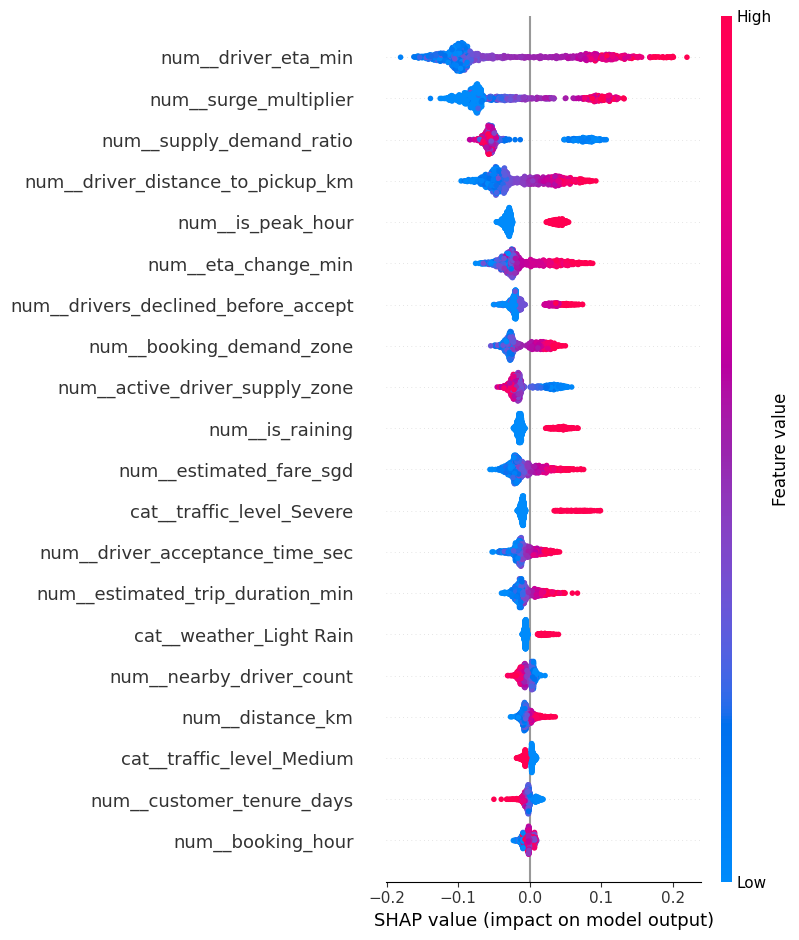

In [ ]:
import shap

# Transform training and test data
X_train_transformed = rf_model.named_steps["preprocess"].transform(X_train)
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed
import shap

# Transform test data
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)

# Convert sparse matrix to dense if needed
X_test_dense = (
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed
)

# Get transformed feature names
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Use a sample
sample_size = 1000
X_shap = X_test_dense[:sample_size]

# Convert X_shap back to DataFrame with feature names
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

# For binary classification: class 1 = customer cancelled
shap_cancelled = shap_values[:, :, 1]

shap.summary_plot(
    shap_cancelled,
    X_shap_df
)
# Use a sample to keep SHAP fast
sample_size = 1000
X_shap = X_test_dense[:sample_size]

explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap)

In [ ]:
#Checking the shape of shap values
print("X_shap shape:", X_shap.shape)
print("Type of shap_values:", type(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)
print(type(X_shap))
print(type(X_shap_df))
print(X_shap.shape)
print(X_shap_df.shape)

X_shap shape: (1000, 117)
Type of shap_values: <class 'numpy.ndarray'>
shap_values shape: (1000, 117, 2)
<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
(1000, 117)
(1000, 117)


In [ ]:
print("rf_importance_df" in globals())

False


#**Section 8. Create final comparison table**

In [ ]:
import pandas as pd

# Get transformed feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get Random Forest feature importances
rf_importances = rf_model.named_steps["model"].feature_importances_

# Create DataFrame
rf_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "RF_Importance": rf_importances
    })
    .sort_values("RF_Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

,Feature,RF_Importance
0,num__driver_eta_min,0.162169
1,num__surge_multiplier,0.129832
2,num__supply_demand_ratio,0.111362
3,num__driver_distance_to_pickup_km,0.067158
4,num__is_peak_hour,0.060520
5,num__active_driver_supply_zone,0.053290
6,num__booking_demand_zone,0.045229
7,num__eta_change_min,0.037788
8,num__drivers_declined_before_accept,0.036647
9,num__estimated_fare_sgd,0.025876


In [ ]:
top_corr = corr_df.head(15)
top_log = log_coef_df.head(15)
top_rf = rf_importance_df.head(15)

print("Top Numeric Correlations")
display(top_corr)

print("Top Logistic Regression Coefficients")
display(top_log)

print("Top Random Forest Importances")
display(top_rf)

Top Numeric Correlations


,Feature,Correlation with customer_cancelled
0,surge_multiplier,0.697512
1,driver_eta_min,0.641218
2,is_peak_hour,0.567279
3,supply_demand_ratio,-0.542120
4,drivers_declined_before_accept,0.523173
5,driver_distance_to_pickup_km,0.480110
6,booking_demand_zone,0.469453
7,active_driver_supply_zone,-0.441864
8,driver_acceptance_time_sec,0.369772
9,estimated_fare_sgd,0.336150


Top Logistic Regression Coefficients


,Feature,Coefficient,Abs_Coefficient
25,num__driver_eta_min,3.251682,3.251682
28,num__surge_multiplier,1.882079,1.882079
96,cat__customer_segment_New,1.623277,1.623277
95,cat__customer_segment_High Value,-1.277430,1.277430
26,num__eta_change_min,1.233861,1.233861
22,num__drivers_declined_before_accept,1.204328,1.204328
110,cat__traffic_level_Severe,0.912459,0.912459
98,cat__customer_segment_Regular,-0.884189,0.884189
30,num__promo_applied,-0.855485,0.855485
8,num__distance_km,0.732039,0.732039


Top Random Forest Importances


,Feature,RF_Importance
0,num__driver_eta_min,0.162169
1,num__surge_multiplier,0.129832
2,num__supply_demand_ratio,0.111362
3,num__driver_distance_to_pickup_km,0.067158
4,num__is_peak_hour,0.060520
5,num__active_driver_supply_zone,0.053290
6,num__booking_demand_zone,0.045229
7,num__eta_change_min,0.037788
8,num__drivers_declined_before_accept,0.036647
9,num__estimated_fare_sgd,0.025876


## **Section 9. Evaluate Model Performance**

In [ ]:
from sklearn.metrics import classification_report

# Evaluate Logistic Regression Model
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1540
           1       0.83      0.94      0.88       460

    accuracy                           0.94      2000
   macro avg       0.91      0.94      0.92      2000
weighted avg       0.95      0.94      0.94      2000



In [ ]:
# Evaluate Random Forest Model
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1540
           1       0.87      0.85      0.86       460

    accuracy                           0.94      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.93      0.94      0.93      2000

